## Import Libraries

In [1]:
! pip install datasets
! pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.4/487.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 10.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import huggingface_hub
import transformers
import datasets
import numpy as np
from pathlib import Path
from datasets import load_dataset,Dataset
from transformers import AutoTokenizer
from transformers import pipeline
import random
from rdkit import Chem
from rdkit.Chem import Draw
from google.colab import files

#import os
#os.environ['WANDB_DISABLED'] = 'true'

In [3]:
def tokenize(batch):
  return tokenizer(batch["text"], padding=True, truncation=True, max_length=250, return_special_tokens_mask=True)

## Sign in to HF hub

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
import os
cpuCount = os.cpu_count()
print("Number of CPUs in the system:", cpuCount)

Number of CPUs in the system: 8


In [ ]:
import sys
print ('Running in colab:', 'google.colab' in sys.modules)

Running in colab: True


## Prep
- Set up model and tokenizer,
- read in dataset to pull molecules
- configure unmasking pipeline
- define the Gen from MultiMask function

In [ ]:
model_size = 55

In [ ]:
model_name = f"cafierom/bert-base-cased-ChemTok-ZN15-{model_size}KStat-V1"
#model_name = "bert-base-cased"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(model_name,padding = True, truncation = True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/4.12k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/672k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/298 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [12]:
ic50s = load_dataset("csv", data_files="/content/905-unique-statins.csv", sep=",",names=["index","text","value"])

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
mask_filler = pipeline("fill-mask", model_name)

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
def gen_from_multimask(text, print_flag=True, mask_flag="random", percent = 0.10, top_k = 3):
  new_tok_list = []
  single_tok = tokenizer(text, padding=True, truncation=True, max_length=250, return_special_tokens_mask=True)
  length_count = 0
  for token in single_tok["input_ids"]:
    if token != 0:
      length_count += 1

  if mask_flag == "last":
    masked_tokens = [*range(int(length_count*(1.0-percent))-1,length_count-1)]
  elif mask_flag == "first":
    masked_tokens = [*range(0,int(length_count*percent))]
  elif mask_flag == "random":
    masked_tokens = random.sample(range(1, length_count), int(length_count*percent))

  for j,token in enumerate(single_tok["input_ids"]):
    if token != 0:
      if j in masked_tokens:
        new_tok_list.append(103)
      else:
        new_tok_list.append(token)
  masked_smile = tokenizer.decode(new_tok_list,
                    skip_special_tokens=False).replace("[PAD]","").replace("[SEP]","").replace("[CLS]","").replace(" ","")
  result = mask_filler(masked_smile,top_k=top_k)

  new_smiles = []
  total_batch = []
  total_entropy = []

  for i in range(len(result)):

    batch_smiles = []
    batch_entropy = []

    for j in range(top_k):

      p = result[i][j]["score"]

      if result[i][j]["score"] > 0.1:
        if i == 0:
          new_smile = result[i][j]["sequence"].replace(" ","").replace("[SEP]","").replace("[CLS]","")
          batch_smiles.append(new_smile)
          batch_entropy.append(-p*np.log(p))
        else:
          for smile,entropy in zip(total_batch[i-1],total_entropy[i-1]):
            new_smile = smile.replace("[MASK]",result[i][j]["token_str"],1)
            batch_smiles.append(new_smile)
            new_entropy = entropy - p*np.log(p)
            batch_entropy.append(new_entropy)

    total_entropy.append(batch_entropy)
    total_batch.append(batch_smiles)

  final_smiles = []
  for smile in total_batch[-1]:
      new_smile = smile.replace("##","")
      final_smiles.append(new_smile)

  if print_flag:
    print(f"original:    {text}")
    final_smiles.insert(0,text)
    for smile in final_smiles:
      print(f"generated:   {smile}")

  return final_smiles,total_entropy[-1]

In [13]:
knowns_list = []
for statin in ic50s["train"]["text"]:
  knowns_list.append(statin)

# for statin in ic50s['test']["text"]:
#   knowns_list.append(statin)

print(f"Dataset has {len(knowns_list)} statins")

Dataset has 906 statins


In [14]:
valid_knowns = []
for smile in knowns_list:
  try:
    mol = Chem.MolFromSmiles(smile)
    if mol is not None:
      valid_knowns.append(smile)
  except:
    print("Could not convert to mol")

print(f"Total known SMILES after removing invalid molecules: {len(valid_knowns)}")

Total known SMILES after removing invalid molecules: 905


[16:54:42] SMILES Parse Error: syntax error while parsing: Ligand
[16:54:42] SMILES Parse Error: check for mistakes around position 1:
[16:54:42] Ligand
[16:54:42] ^
[16:54:42] SMILES Parse Error: Failed parsing SMILES 'Ligand' for input: 'Ligand'


## Perform MaskGen

In [ ]:
how_many_statins = 1
percent_to_use = 0.10
which_statins = random.sample(range(len(knowns_list)), how_many_statins)
which_statins =[663]
print(f"Using statins: {which_statins} with IC50 {ic50s['train']['value'][which_statins[0]]}")

Using statins: [663] with IC50  3


In [ ]:
main_smiles = []
main_entropy = []

for statin in which_statins:
  result, calc_entropy = gen_from_multimask(knowns_list[statin], print_flag=False, mask_flag = "first", percent=percent_to_use)
  for smile,entropy in zip(result,calc_entropy):
    if smile not in main_smiles:
      main_smiles.append(smile)
      main_entropy.append(entropy)
  length = len(main_smiles)
  print(f"First masking generated {length} SMILES")

  result, calc_entropy = gen_from_multimask(knowns_list[statin], print_flag=False, mask_flag = "last", percent=percent_to_use)
  for smile,entropy in zip(result,calc_entropy):
    if smile not in main_smiles:
      main_smiles.append(smile)
      main_entropy.append(entropy)
  print(f"Last masking generated {len(main_smiles)-length} SMILES")
  length = len(main_smiles)

  for _ in range(4):
    result, calc_entropy = gen_from_multimask(knowns_list[statin], print_flag=False, mask_flag = "random", percent=percent_to_use)
    for smile,entropy in zip(result,calc_entropy):
      if smile not in main_smiles:
        main_smiles.append(smile)
        main_entropy.append(entropy)
    print(f"Random masking generated {len(main_smiles)-length} SMILES")
    length = len(main_smiles)

print(f"Total SMILES generated: {len(main_smiles)}")

main_smiles = list(set(main_smiles))
print(f"Total SMILES generated after removing duplicates: {len(main_smiles)}")

First masking generated 36 SMILES
Last masking generated 24 SMILES
Random masking generated 2 SMILES
Random masking generated 3 SMILES
Random masking generated 5 SMILES
Random masking generated 4 SMILES
Total SMILES generated: 74
Total SMILES generated after removing duplicates: 74


In [ ]:
mols = []
valid_smiles = []
valid_entropies = []
for smile,entropy in zip(main_smiles,main_entropy):
  try:
    mol = Chem.MolFromSmiles(smile)
    if mol is not None:
      mols.append(mol)
      valid_smiles.append(smile)
      valid_entropies.append(entropy)
  except:
    print("Could not convert to mol")

print(f"Total SMILES after removing invalid molecules: {len(valid_smiles)}")

Total SMILES after removing invalid molecules: 14


[14:02:15] SMILES Parse Error: unclosed ring for input: 'O[C@H](C[C@H](O)\C=C\c1c2CCCC(Cc3ccc(cc3)-c3ccccc3)c2nn1-c1ccc(F)cc1)Cc1ccccCO'
[14:02:15] SMILES Parse Error: syntax error while parsing: CN((C[C@H](O)\C=C\c1c2CCCC(Cc3ccc(cc3)-c3ccccc3)c2nn1-c1ccc(F)cc1)CC([O-])=O
[14:02:15] SMILES Parse Error: check for mistakes around position 4:
[14:02:15] CN((C[C@H](O)\C=C\c1c2CCCC(Cc3ccc(cc3)-c3
[14:02:15] ~~~^
[14:02:15] SMILES Parse Error: Failed parsing SMILES 'CN((C[C@H](O)\C=C\c1c2CCCC(Cc3ccc(cc3)-c3ccccc3)c2nn1-c1ccc(F)cc1)CC([O-])=O' for input: 'CN((C[C@H](O)\C=C\c1c2CCCC(Cc3ccc(cc3)-c3ccccc3)c2nn1-c1ccc(F)cc1)CC([O-])=O'
[14:02:15] non-ring atom 37 marked aromatic
[14:02:15] SMILES Parse Error: syntax error while parsing: CC=C(([C@H](O)\C=C\c1c2CCCC(Cc3ccc(cc3)-c3ccccc3)c2nn1-c1ccc(F)cc1)CC([O-])=O
[14:02:15] SMILES Parse Error: check for mistakes around position 6:
[14:02:15] CC=C(([C@H](O)\C=C\c1c2CCCC(Cc3ccc(cc3)-c
[14:02:15] ~~~~~^
[14:02:15] SMILES Parse Error: Failed parsing 

In [ ]:
unique_smiles = []
unique_entropies = []

canon_smiles = [Chem.CanonSmiles(smile) for smile in valid_smiles]
canon_knowns = [Chem.CanonSmiles(smile) for smile in valid_knowns]

for smile,entropy in zip(canon_smiles,valid_entropies):
  if smile not in canon_knowns:
    unique_smiles.append(smile)
    unique_entropies.append(entropy)

print(f"Total unique SMILES generated: {len(unique_smiles)}")
print(f"Average entropy: {sum(unique_entropies)/len(unique_entropies)}")

dict_smiles =  unique_smiles
dict_entropies = unique_entropies
dict_smiles.insert(0,knowns_list[which_statins[0]])
dict_entropies.insert(0,0.0)
dict = {"smiles":dict_smiles, "entropies":dict_entropies}
df = pd.DataFrame(dict)
filename = f"statin{which_statins[0]}_{model_size}K_fullgen{int(percent_to_use*100)}p"
df.to_csv(filename+".csv")
files.download(filename+".csv")
print(f"saved to {filename}")

Total unique SMILES generated: 13
Average entropy: 1.6479184431923808


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

saved to statin663_55K_fullgen10p


## Visualize generated molecules

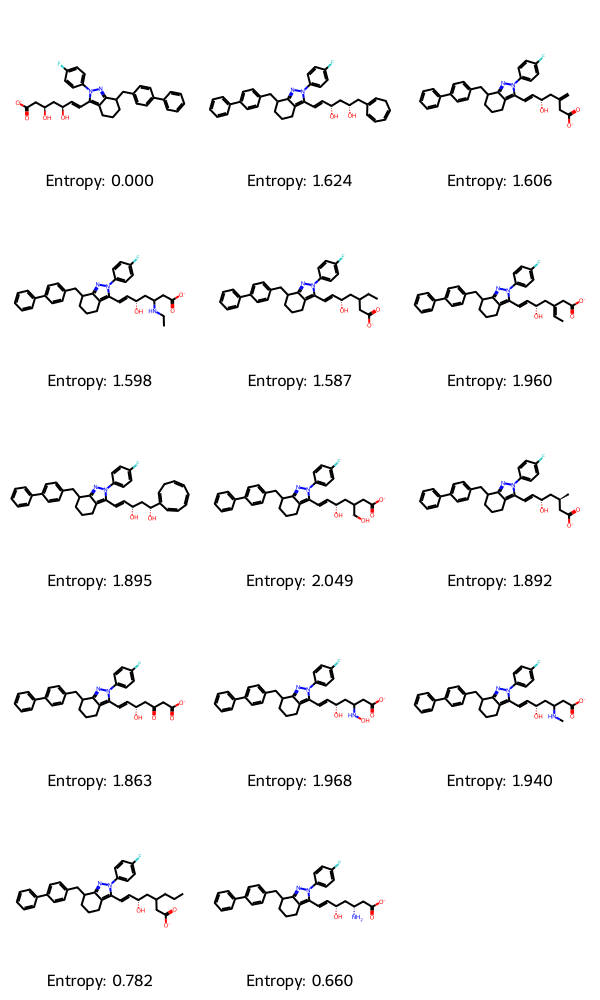

In [ ]:
mols = [Chem.MolFromSmiles(smile) for smile in dict_smiles]
legends = []
for entropy in dict_entropies:
  legends.append(f"Entropy: {entropy:.3f}")
Draw.MolsToGridImage(mols, legends=legends,molsPerRow=3, subImgSize=(200,200))

## Analyze seed molecules

In [20]:
from rdkit.Chem import QED

In [24]:
statins_to_analyze = [663,877,867,45,360,176,677,786,872,767]

smiles_to_analyze = []
for idx in statins_to_analyze:
  smiles_to_analyze.append(knowns_list[idx])

mols = [Chem.MolFromSmiles(smile) for smile in smiles_to_analyze]
legends = []

MW_list = []
length_list = []

for smile in smiles_to_analyze:
  mol = Chem.MolFromSmiles(smile)
  qed_descriptor = Chem.QED.default(mol)
  p = Chem.QED.properties(mol)
  MW_list.append(p[0])
  length_list.append(len(smile))
  legends.append(f"MW: {p[0]:.3f}, length: {len(smile)}")


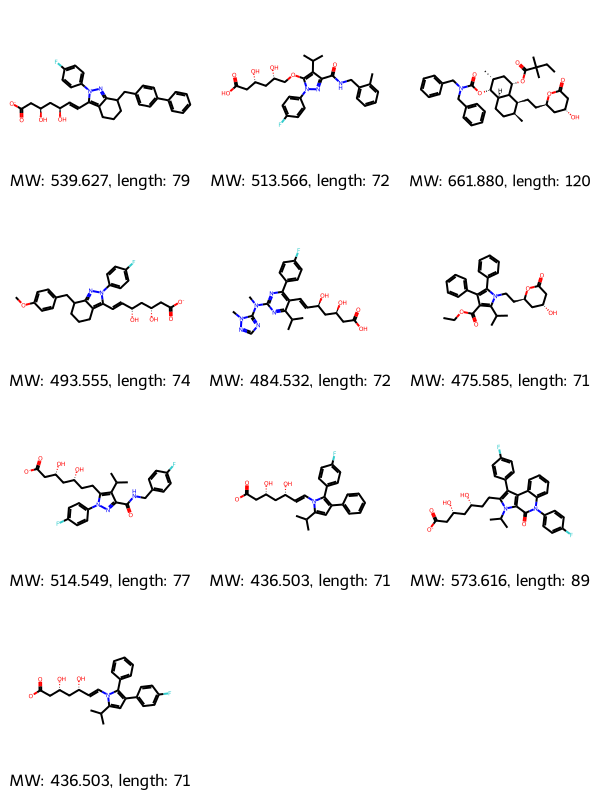

In [25]:
Draw.MolsToGridImage(mols, legends = legends, molsPerRow=3, subImgSize=(200,200))

In [26]:
img = Draw.MolsToGridImage(mols, legends = legends, molsPerRow=3, subImgSize=(200,200))
pic = img.data

with open("Statin_seeds.png",'wb+') as outf:
    outf.write(pic)

files.download("Statin_seeds.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>